<cell_type>markdown</cell_type># Trans Effects Comparison

Cross-dataset comparison of trans-regulatory effects from calibrated results:
- Positive control # of cells barplots
- Positive control # of DEGs barplots  
- Positive control Venn diagrams of DEGs + Jaccard (using gene IDs, displaying symbols)
- Pairwise Jaccard similarity distributions
- Per-element pathway enrichment heatmaps
- TF target enrichment comparison (CLEANSER vs Sceptre)

**Known data issue:** Some datasets (Huangfu, Engreitz) have missing `element_symbol` in
calibrated results. This is fixed at load time using a cross-dataset ENSG→symbol lookup.
Overlap computations use `tested_gene_id` (not symbols) for robustness.

**Input:** Calibrated trans results + pathway results from `calibration/` dirs  
**Output:** Combined tables and comparison plots

In [17]:
import os
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [18]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

In [19]:
# Parameters
RUN_LABEL = "cleanser_unified"
FDR_THRESHOLD = 0.10


In [20]:
# Derived paths
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL / "inference"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_ROOT = PROJECT_ROOT / "datasets"

DATASETS = [
    "Hon_WTC11-benchmark_TF-Perturb-seq",
    "Huangfu_WTC11-benchmark_TF-Perturb-seq",
    "Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3",
    "Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2",
    "Engreitz_WTC11-benchmark_TF-Perturb-seq",
]

SUFFIX = "_WTC11-benchmark_TF-Perturb-seq"
def short_name(ds):
    return ds.replace(SUFFIX, "").replace("_", " ")

print(f"Run label: {RUN_LABEL}")
print(f"FDR threshold: {FDR_THRESHOLD}")
print(f"Output directory: {OUTPUT_DIR}")

Run label: cleanser_unified
FDR threshold: 0.1
Output directory: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/inference


In [21]:
# Load trans results (excluding cis) and pathway results
trans_results = {}
pathway_results = {}

for ds in DATASETS:
    cal_dir = DATASETS_ROOT / ds / "runs" / RUN_LABEL / "calibration"
    
    trans_path = cal_dir / f"{ds}_calibrated_trans_results.tsv"
    pw_path = cal_dir / f"{ds}_calibrated_pathway_results.tsv"
    
    if trans_path.exists():
        trans_results[ds] = pd.read_csv(trans_path, sep="\t", low_memory=False)
        trans_results[ds]["dataset"] = ds
        print(f"  {short_name(ds)}: {len(trans_results[ds]):,} trans tests")
    else:
        print(f"  {short_name(ds)}: MISSING trans results")
    
    if pw_path.exists():
        pathway_results[ds] = pd.read_csv(pw_path, sep="\t")
        pathway_results[ds]["dataset"] = ds
        print(f"    → {len(pathway_results[ds]):,} pathway enrichments")

# --- Fix missing element_symbol across datasets ---
# Build a cross-dataset lookup: ENSG -> symbol from any dataset that has it
ensg_to_symbol = {}
for ds, df in trans_results.items():
    for eid, sym in df.drop_duplicates("element_id")[["element_id", "element_symbol"]].values:
        if pd.notna(sym):
            ensg = eid.split("|")[0]
            ensg_to_symbol[ensg] = sym

# Fill missing symbols
for ds, df in trans_results.items():
    mask = df["element_symbol"].isna()
    if mask.any():
        df.loc[mask, "element_symbol"] = df.loc[mask, "element_id"].apply(
            lambda eid: ensg_to_symbol.get(eid.split("|")[0], np.nan)
        )
        n_fixed = mask.sum() - df["element_symbol"].isna().sum()
        n_still_missing = df["element_symbol"].isna().sum()
        print(f"  {short_name(ds)}: fixed {n_fixed:,} rows with missing symbol"
              f" ({n_still_missing:,} still missing — non-targeting or unmapped)")

print(f"\nLoaded {len(trans_results)} trans, {len(pathway_results)} pathway datasets")

  Hon: 692,004 trans tests
    → 36,627 pathway enrichments
  Huangfu: 620,536 trans tests
    → 54,114 pathway enrichments
  Gersbach GEM-Xv3: 1,008,385 trans tests
    → 37,923 pathway enrichments
  Gersbach HTv2: 947,412 trans tests
    → 34,002 pathway enrichments
  Engreitz: 362,386 trans tests
    → 29,747 pathway enrichments
  Hon: fixed 93,528 rows with missing symbol (177,704 still missing — non-targeting or unmapped)
  Huangfu: fixed 83,853 rows with missing symbol (159,348 still missing — non-targeting or unmapped)
  Gersbach GEM-Xv3: fixed 0 rows with missing symbol (258,943 still missing — non-targeting or unmapped)
  Gersbach HTv2: fixed 12,805 rows with missing symbol (243,287 still missing — non-targeting or unmapped)
  Engreitz: fixed 93,046 rows with missing symbol (93,060 still missing — non-targeting or unmapped)

Loaded 5 trans, 5 pathway datasets


## Per-Element DEG Counts

Number of cells and significant trans DEGs per element, split by target type.

In [22]:
# Compute per-element summary: n_cells, n_degs, element_label
element_summaries = []

for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    targeting = df[df["element_label"].str.lower().str.replace("-", "_") != "non_targeting"]
    
    sig = targeting[targeting["empirical_pval_adj"] < FDR_THRESHOLD]
    
    # Per-element DEG counts
    deg_counts = sig.groupby("element_id").agg(
        n_degs=("tested_gene_id", "count"),
        n_up=("log2fc", lambda x: (x > 0).sum()),
        n_down=("log2fc", lambda x: (x < 0).sum()),
    ).reset_index()
    
    # Merge with element metadata (n_cells, label, symbol)
    meta = targeting.drop_duplicates("element_id")[["element_id", "element_symbol", "element_label", "n_cells"]]
    deg_counts = meta.merge(deg_counts, on="element_id", how="left").fillna({"n_degs": 0, "n_up": 0, "n_down": 0})
    deg_counts["dataset"] = ds
    element_summaries.append(deg_counts)

elem_df = pd.concat(element_summaries, ignore_index=True)
elem_df["dataset"] = pd.Categorical(elem_df["dataset"], categories=dataset_order, ordered=True)
elem_df["lab"] = elem_df["dataset"].astype(str).apply(short_name)

# Save
elem_df.to_csv(OUTPUT_DIR / "per_element_deg_summary.tsv", sep="\t", index=False)
print(f"Per-element summary: {len(elem_df)} elements across {elem_df['dataset'].nunique()} datasets")
elem_df.head()

Per-element summary: 345 elements across 5 datasets


,element_id,element_symbol,element_label,n_cells,n_degs,n_up,n_down,dataset,lab
0,ENSG00000005339|chr16:3880184-3880693,CREBBP,targeting,1197,61.0,45.0,16.0,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
1,ENSG00000008083|chr6:15245952-15246085,JARID2,targeting,800,5.0,4.0,1.0,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
2,ENSG00000049618|chr6:156777663-156778009,ARID1B,targeting,1543,3.0,3.0,0.0,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
3,ENSG00000049618|chr6:156779041-156779230,ARID1B,targeting,1624,4.0,4.0,0.0,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
4,ENSG00000066117|chr12:50085236-50085698,SMARCD1,targeting,1011,0.0,0.0,0.0,Hon_WTC11-benchmark_TF-Perturb-seq,Hon


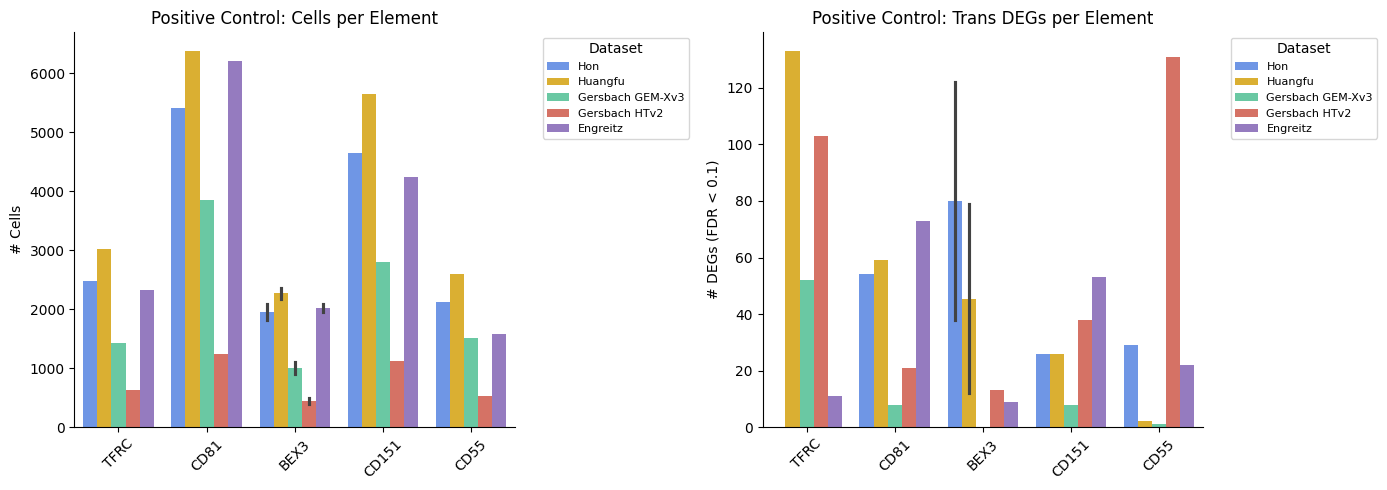

In [23]:
# Positive control barplots: n_cells and n_degs
pos_ctrl = elem_df[elem_df["element_label"] == "positive control"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# n_cells
ax = axes[0]
sns.barplot(data=pos_ctrl, x="element_symbol", y="n_cells", hue="lab", 
            palette={short_name(ds): dataset_colors[ds] for ds in dataset_order}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("# Cells")
ax.set_title("Positive Control: Cells per Element")
ax.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# n_degs
ax = axes[1]
sns.barplot(data=pos_ctrl, x="element_symbol", y="n_degs", hue="lab",
            palette={short_name(ds): dataset_colors[ds] for ds in dataset_order}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel(f"# DEGs (FDR < {FDR_THRESHOLD})")
ax.set_title("Positive Control: Trans DEGs per Element")
ax.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "posctrl_cells_and_degs.pdf", dpi=300, bbox_inches="tight")
plt.show()

## DEG Overlap: Venn Diagrams and Jaccard Similarity

For positive controls, compare which DEGs are shared across datasets.

In [24]:
# Build DEG sets per (element_symbol, dataset) for positive controls
# Use gene IDs for set operations (some genes lack symbols), display symbols in plots

def jaccard(a, b):
    if len(a) == 0 and len(b) == 0:
        return np.nan
    return len(a & b) / len(a | b)

# Build gene ID -> symbol lookup across all datasets
gene_id_to_symbol = {}
for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    for gid, gsym in df[["tested_gene_id", "tested_gene_symbol"]].drop_duplicates("tested_gene_id").values:
        if pd.notna(gsym) and gid not in gene_id_to_symbol:
            gene_id_to_symbol[gid] = gsym

# Get sig DEG gene ID sets per element per dataset
deg_sets = {}  # (element_symbol, dataset) -> set of gene IDs
for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    sig = df[(df["empirical_pval_adj"] < FDR_THRESHOLD) & (df["element_label"] == "positive control")]
    for elem, grp in sig.groupby("element_symbol"):
        deg_sets[(elem, ds)] = set(grp["tested_gene_id"].dropna())

# Compute pairwise Jaccard for each element
elements = sorted(set(e for e, _ in deg_sets.keys()))
ds_pairs = list(combinations([ds for ds in dataset_order if ds in trans_results], 2))

jaccard_rows = []
for elem in elements:
    for ds1, ds2 in ds_pairs:
        s1 = deg_sets.get((elem, ds1), set())
        s2 = deg_sets.get((elem, ds2), set())
        if len(s1) == 0 and len(s2) == 0:
            continue
        shared_ids = s1 & s2
        shared_symbols = sorted(gene_id_to_symbol.get(g, g) for g in shared_ids)
        jaccard_rows.append({
            "element": elem,
            "dataset_1": short_name(ds1),
            "dataset_2": short_name(ds2),
            "jaccard": jaccard(s1, s2),
            "n_shared": len(shared_ids),
            "n_union": len(s1 | s2),
            "n_ds1": len(s1),
            "n_ds2": len(s2),
            "shared_genes": ", ".join(shared_symbols),
        })

jaccard_df = pd.DataFrame(jaccard_rows)
jaccard_df.to_csv(OUTPUT_DIR / "posctrl_deg_jaccard.tsv", sep="\t", index=False)
print(f"Pairwise Jaccard: {len(jaccard_df)} comparisons across {len(elements)} positive controls")
print(f"Positive controls found: {elements}")
jaccard_df.head(10)

Pairwise Jaccard: 50 comparisons across 5 positive controls
Positive controls found: ['BEX3', 'CD151', 'CD55', 'CD81', 'TFRC']


,element,dataset_1,dataset_2,jaccard,n_shared,n_union,n_ds1,n_ds2,shared_genes
0,BEX3,Hon,Huangfu,0.020661,5,242,157,90,"MT-CO1, MT-RNR2, RPL7A, TMSB4X, USP48"
1,BEX3,Hon,Gersbach GEM-Xv3,0.000000,0,157,157,0,
2,BEX3,Hon,Gersbach HTv2,0.011561,2,173,157,18,"MT-CO1, MT-RNR2"
3,BEX3,Hon,Engreitz,0.005780,1,173,157,17,RPS19
4,BEX3,Huangfu,Gersbach GEM-Xv3,0.000000,0,90,90,0,
5,BEX3,Huangfu,Gersbach HTv2,0.069307,7,101,90,18,"MT-CO1, MT-CO2, MT-CO3, MT-CYB, MT-ND3, MT-ND6..."
6,BEX3,Huangfu,Engreitz,0.009434,1,106,90,17,RPS27A
7,BEX3,Gersbach GEM-Xv3,Gersbach HTv2,0.000000,0,18,0,18,
8,BEX3,Gersbach GEM-Xv3,Engreitz,0.000000,0,17,0,17,
9,BEX3,Gersbach HTv2,Engreitz,0.000000,0,35,18,17,


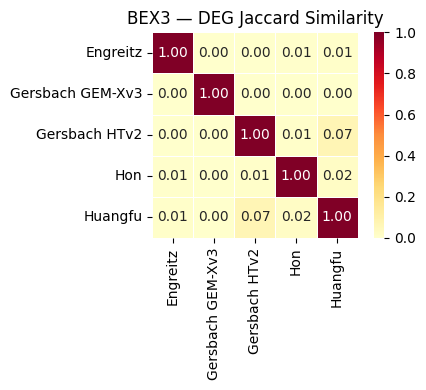

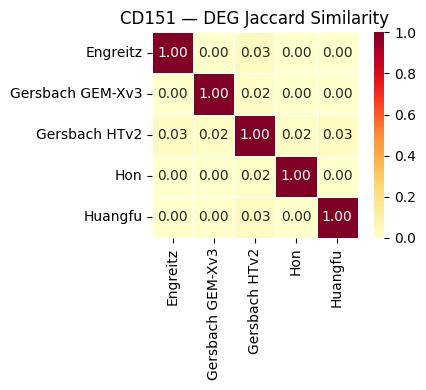

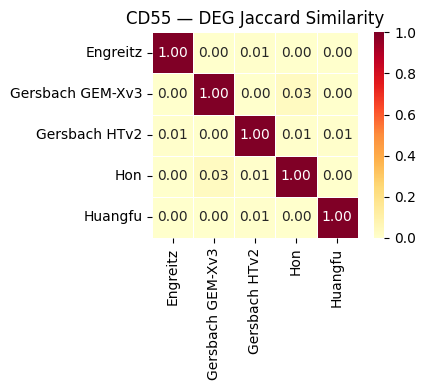

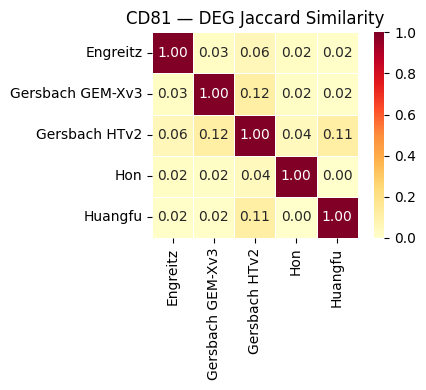

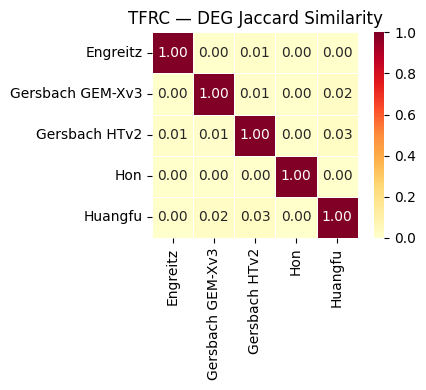

In [25]:
# Jaccard heatmap per positive control element
for elem in elements:
    elem_j = jaccard_df[jaccard_df["element"] == elem]
    if elem_j.empty:
        continue
    
    # Build symmetric matrix
    labs = sorted(set(elem_j["dataset_1"]) | set(elem_j["dataset_2"]))
    mat = pd.DataFrame(1.0, index=labs, columns=labs)
    for _, row in elem_j.iterrows():
        mat.loc[row["dataset_1"], row["dataset_2"]] = row["jaccard"]
        mat.loc[row["dataset_2"], row["dataset_1"]] = row["jaccard"]
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
                square=True, linewidths=0.5)
    ax.set_title(f"{elem} — DEG Jaccard Similarity")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"jaccard_heatmap_{elem}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace

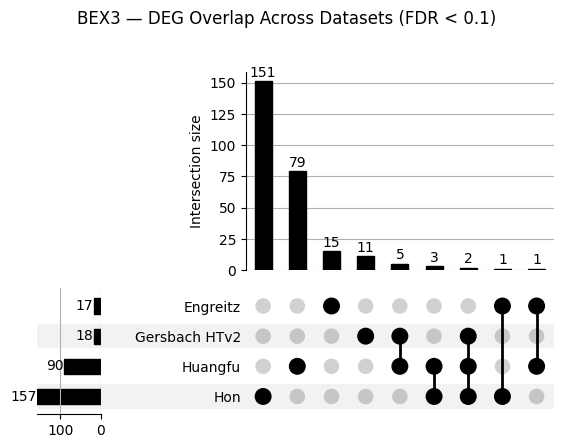

  BEX3 — no genes shared across all 4 datasets


/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace

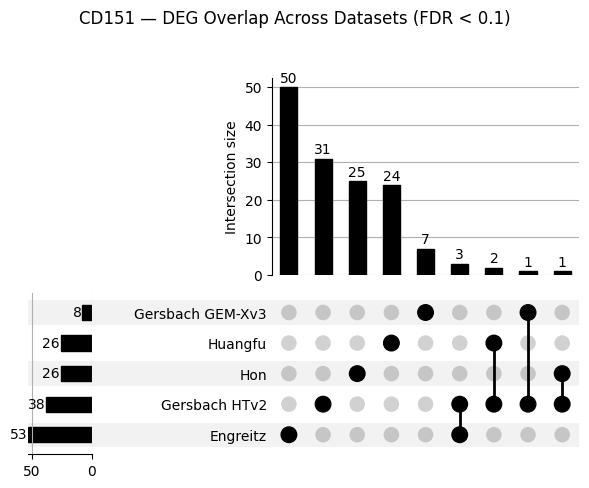

  CD151 — no genes shared across all 5 datasets


/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace

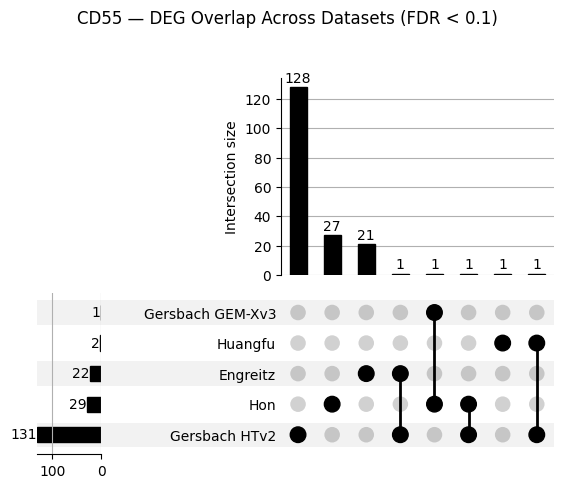

  CD55 — no genes shared across all 5 datasets


/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace

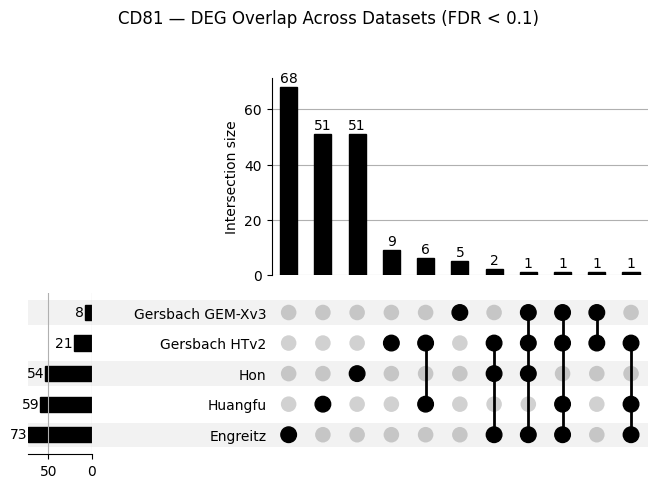

  CD81 — no genes shared across all 5 datasets


/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/cellar/users/aklie/data/datasets/tf_perturb_seq/.venv/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace

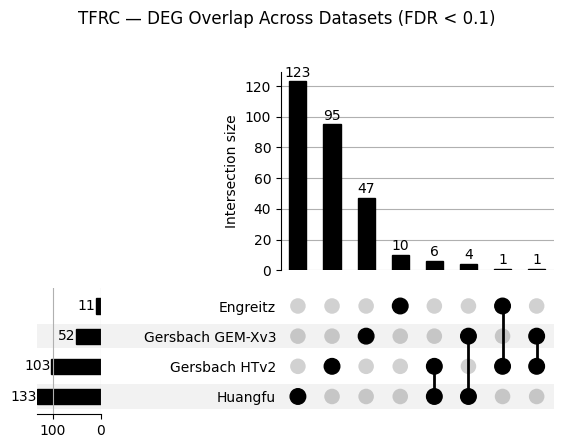

  TFRC — no genes shared across all 4 datasets


In [29]:
# UpSet plots for each positive control: show DEG overlap structure across datasets
from upsetplot import UpSet, from_memberships

for elem in elements:
    # Collect DEG sets per dataset for this element
    elem_sets = {}
    for ds in dataset_order:
        if (elem, ds) in deg_sets and len(deg_sets[(elem, ds)]) > 0:
            elem_sets[short_name(ds)] = deg_sets[(elem, ds)]
    
    if len(elem_sets) < 2:
        print(f"{elem}: only {len(elem_sets)} dataset(s) with DEGs, skipping UpSet")
        continue
    
    # Build membership list for upsetplot (deduplicate by converting to tuples)
    all_genes = set()
    for s in elem_sets.values():
        all_genes |= s
    
    memberships = []
    for gene_id in sorted(all_genes):
        member_of = tuple(sorted(ds_name for ds_name, gene_set in elem_sets.items() if gene_id in gene_set))
        memberships.append(member_of)
    
    # from_memberships needs a count per unique combination
    membership_counts = pd.Series(memberships).value_counts()
    membership_series = from_memberships(
        membership_counts.index.tolist(),
        data=membership_counts.values,
    )
    
    upset = UpSet(membership_series, show_counts=True, sort_by="cardinality",
                  min_subset_size=1)
    fig = plt.figure(figsize=(10, 5))
    upset.plot(fig=fig)
    fig.suptitle(f"{elem} — DEG Overlap Across Datasets (FDR < {FDR_THRESHOLD})",
                 fontsize=12, y=1.02)
    plt.savefig(OUTPUT_DIR / f"upset_{elem}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Also print shared genes for the intersection of all datasets
    if len(elem_sets) >= 2:
        all_shared = set.intersection(*elem_sets.values())
        if all_shared:
            shared_symbols = sorted(gene_id_to_symbol.get(g, g) for g in all_shared)
            print(f"  {elem} — genes in ALL {len(elem_sets)} datasets: {', '.join(shared_symbols)}")
        else:
            print(f"  {elem} — no genes shared across all {len(elem_sets)} datasets")

## Pairwise Jaccard Distributions

Distribution of Jaccard similarities across all TF-targeting elements (not just positive controls).

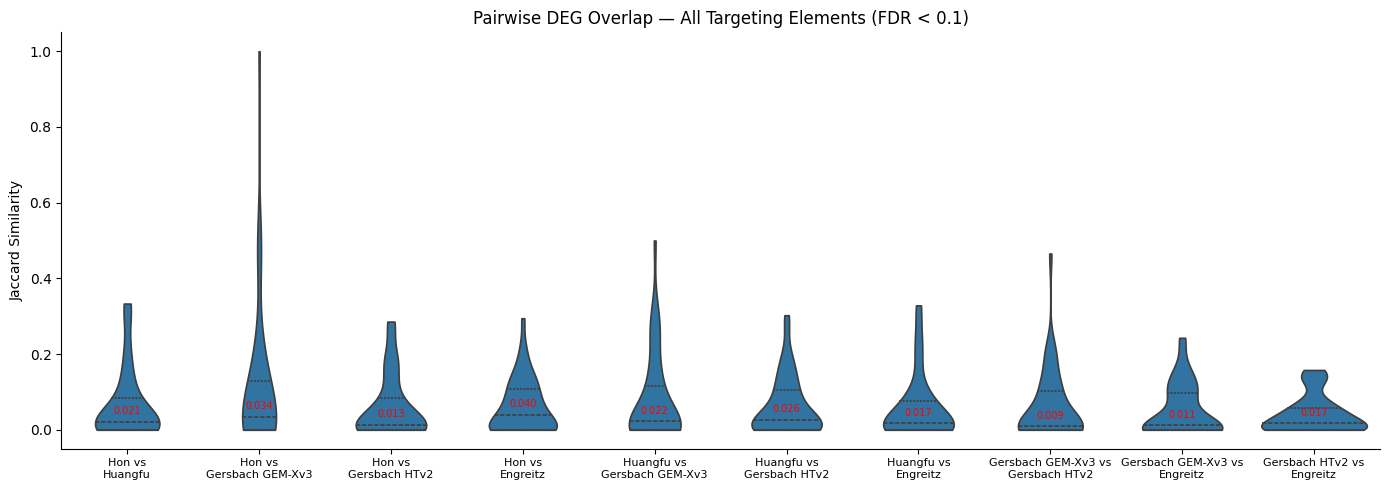

In [ ]:
# Compute Jaccard for ALL targeting elements (not just positive controls)
# Uses gene IDs for set operations
all_deg_sets = {}
for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    sig = df[df["empirical_pval_adj"] < FDR_THRESHOLD]
    for elem, grp in sig.groupby("element_symbol"):
        all_deg_sets[(elem, ds)] = set(grp["tested_gene_id"].dropna())

all_elements = sorted(set(e for e, _ in all_deg_sets.keys()))

all_jaccard_rows = []
for ds1, ds2 in ds_pairs:
    for elem in all_elements:
        s1 = all_deg_sets.get((elem, ds1), set())
        s2 = all_deg_sets.get((elem, ds2), set())
        if len(s1) == 0 and len(s2) == 0:
            continue
        j = jaccard(s1, s2)
        all_jaccard_rows.append({
            "element": elem,
            "pair": f"{short_name(ds1)} vs\n{short_name(ds2)}",
            "jaccard": j,
        })

all_jaccard_df = pd.DataFrame(all_jaccard_rows)

# Violin plot of Jaccard distributions per dataset pair
fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=all_jaccard_df, x="pair", y="jaccard", inner="quartile", cut=0, ax=ax)
ax.set_ylabel("Jaccard Similarity")
ax.set_xlabel("")
ax.set_title(f"Pairwise DEG Overlap — All Targeting Elements (FDR < {FDR_THRESHOLD})")
ax.tick_params(axis="x", rotation=0, labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add median annotation
medians = all_jaccard_df.groupby("pair", sort=False)["jaccard"].median()
for i, (pair, med) in enumerate(medians.items()):
    ax.text(i, med + 0.02, f"{med:.3f}", ha="center", fontsize=7, color="red")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "jaccard_pairwise_distributions.pdf", dpi=300, bbox_inches="tight")
plt.show()

<cell_type>markdown</cell_type>## Pathway Enrichment Comparison

For each positive control, compare significant GO BP pathway enrichments across datasets.
Focus on whether biologically expected pathways are recovered.

In [ ]:
# Combine pathway results and fix missing element_symbol
if pathway_results:
    pw_combined = pd.concat(pathway_results.values(), ignore_index=True)
    
    # Fix missing element_symbol using the same cross-dataset lookup
    mask = pw_combined["element_symbol"].isna()
    if mask.any():
        pw_combined.loc[mask, "element_symbol"] = pw_combined.loc[mask, "element_id"].apply(
            lambda eid: ensg_to_symbol.get(eid.split("|")[0], np.nan)
        )
        print(f"Fixed {mask.sum() - pw_combined['element_symbol'].isna().sum()} pathway rows with missing symbol")
    
    pw_combined["dataset"] = pd.Categorical(pw_combined["dataset"], categories=dataset_order, ordered=True)
    pw_combined["lab"] = pw_combined["dataset"].astype(str).apply(short_name)
    
    # Save
    pw_combined.to_csv(OUTPUT_DIR / "combined_pathway_results.tsv", sep="\t", index=False)
    
    # Significant pathways per element per dataset
    pw_sig = pw_combined[pw_combined["pvalue_adj"] < 0.05]
    print(f"Total pathway enrichments: {len(pw_combined):,}")
    print(f"Significant (FDR < 0.05): {len(pw_sig):,}")
    print(f"Unique pathways: {pw_sig['pathway_id'].nunique()}")
    print(f"Elements with sig pathways: {pw_sig['element_id'].nunique()}")
else:
    print("No pathway results available")

Fixed 13573 pathway rows with missing symbol
Total pathway enrichments: 192,413
Significant (FDR < 0.05): 7,371
Unique pathways: 2247
Elements with sig pathways: 66


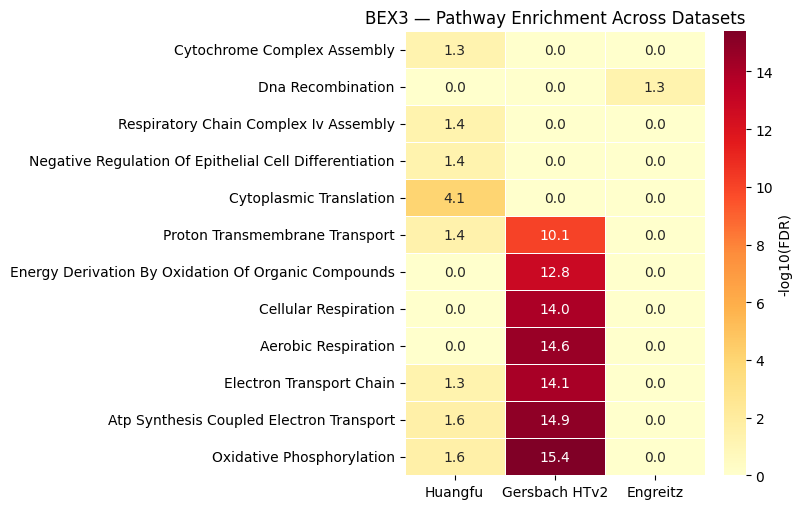

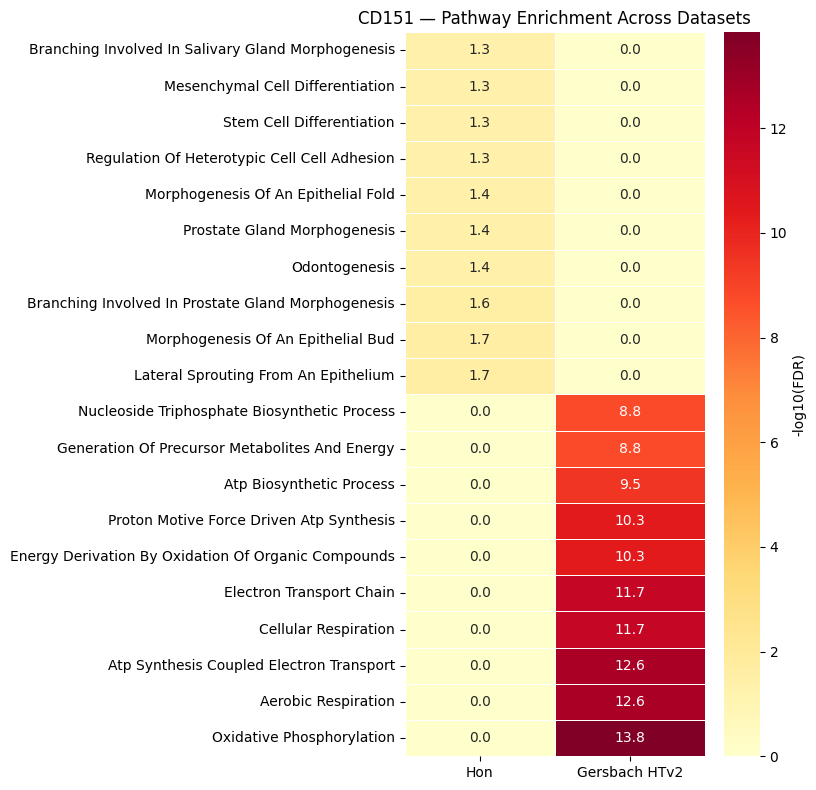

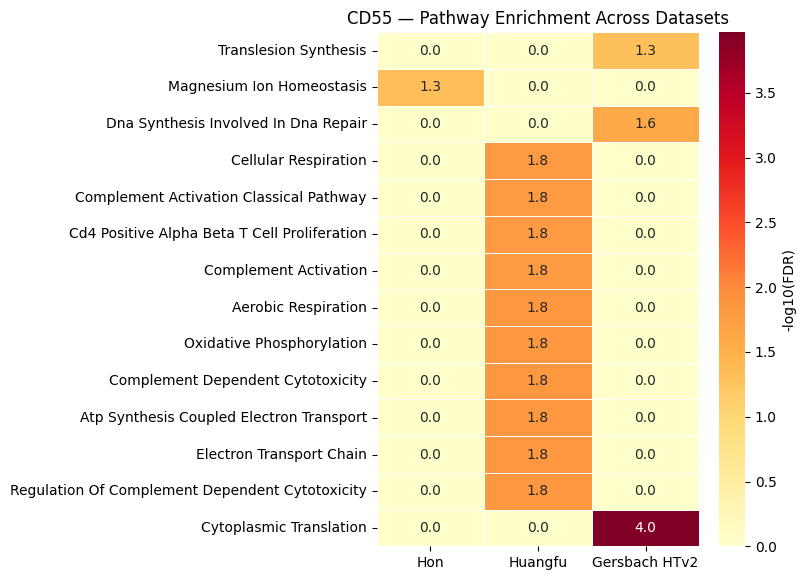

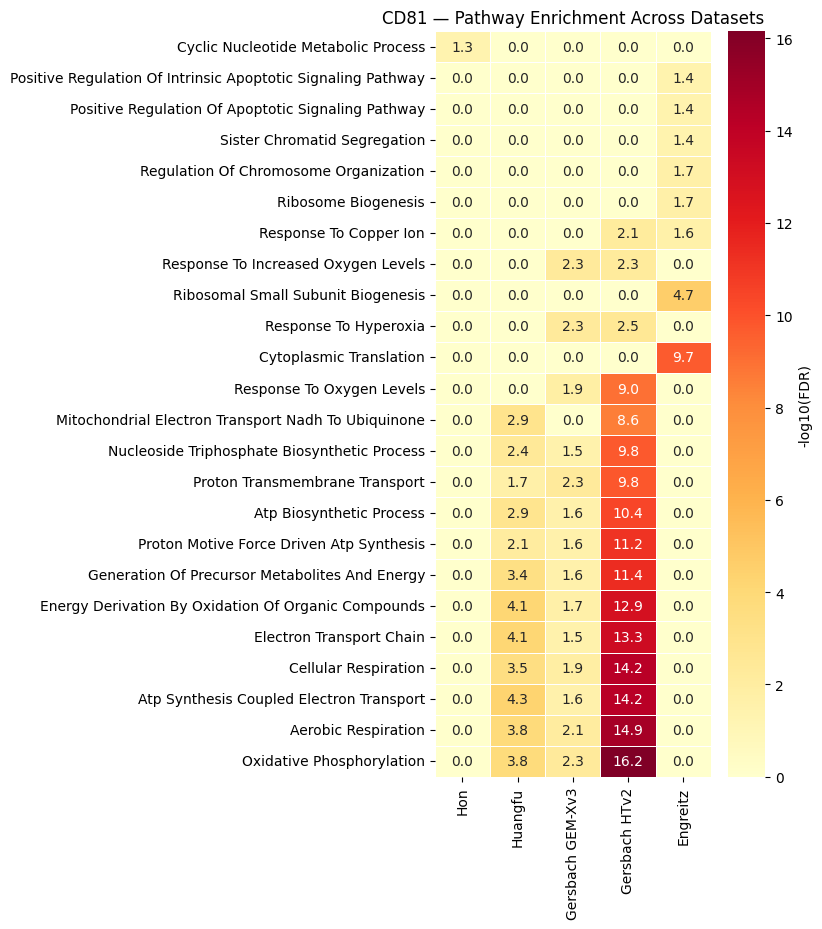

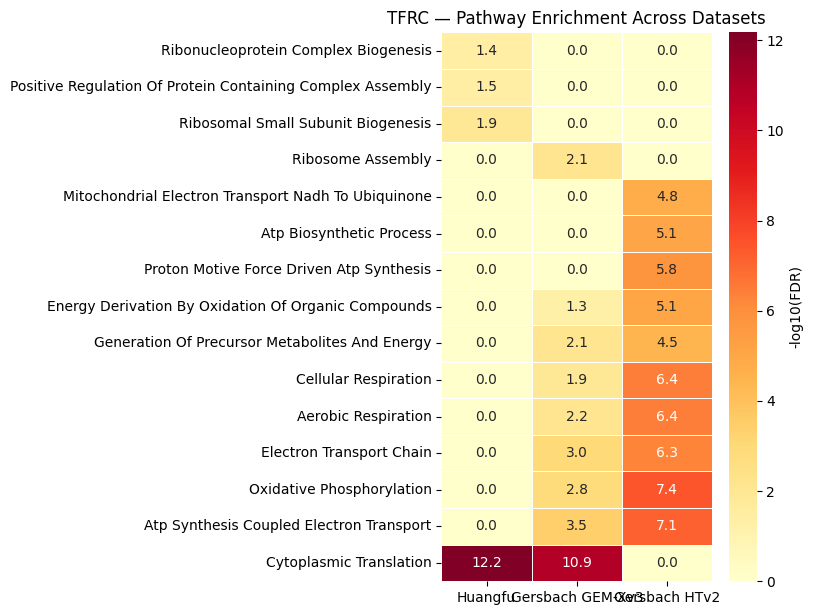

In [ ]:
# Per-positive-control pathway heatmap: which pathways are enriched in which datasets?
if pathway_results:
    posctrl_symbols = sorted(elements)  # from the Jaccard section
    
    for elem in posctrl_symbols:
        # Get significant pathways for this element across all datasets
        elem_pw = pw_sig[pw_sig["element_symbol"] == elem].copy()
        if elem_pw.empty:
            print(f"{elem}: no significant pathways in any dataset")
            continue
        
        # Clean pathway names for display
        elem_pw["pw_short"] = elem_pw["pathway_name"].apply(
            lambda x: x.split("/")[-1].replace("GOBP_", "").replace("_", " ").title() if "/" in str(x)
            else str(x).replace("GOBP_", "").replace("_", " ").title()
        )
        
        # Pivot: pathway × dataset, values = -log10(pvalue_adj)
        elem_pw["neg_log10_padj"] = -np.log10(elem_pw["pvalue_adj"].clip(lower=1e-50))
        
        # Take union of top 10 pathways per dataset (by p-value)
        top_pathways = set()
        for ds_lab in elem_pw["lab"].unique():
            ds_top = elem_pw[elem_pw["lab"] == ds_lab].nsmallest(10, "pvalue_adj")
            top_pathways.update(ds_top["pw_short"].values)
        
        if len(top_pathways) == 0:
            continue
        
        # Build matrix
        pivot = elem_pw[elem_pw["pw_short"].isin(top_pathways)].pivot_table(
            index="pw_short", columns="lab", values="neg_log10_padj", aggfunc="max"
        )
        
        # Order columns by dataset_order
        ds_labs = [short_name(ds) for ds in dataset_order if short_name(ds) in pivot.columns]
        pivot = pivot.reindex(columns=ds_labs)
        
        # Order rows by total enrichment (sum across datasets)
        pivot = pivot.fillna(0)
        pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]
        
        fig_height = max(4, len(pivot) * 0.35 + 1)
        fig, ax = plt.subplots(figsize=(8, fig_height))
        
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "-log10(FDR)"})
        ax.set_title(f"{elem} — Pathway Enrichment Across Datasets")
        ax.set_ylabel("")
        ax.set_xlabel("")
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"pathway_heatmap_{elem}.pdf", dpi=300, bbox_inches="tight")
        plt.show()
    
    # Also save the frequency summary (but don't plot the generic bar chart)
    pw_freq = pw_sig.groupby("pathway_name").agg(
        n_element_dataset_pairs=("element_id", "count"),
        n_datasets=("dataset", "nunique"),
        n_elements=("element_symbol", "nunique"),
        mean_fold_enrichment=("fold_enrichment", "mean"),
    ).sort_values("n_element_dataset_pairs", ascending=False)
    pw_freq.to_csv(OUTPUT_DIR / "pathway_frequency_summary.tsv", sep="\t")

<cell_type>markdown</cell_type>## TF Target Enrichment Comparison

For TFs with known ChIP-seq targets, test whether trans DEGs are enriched for direct targets.
Compare across datasets and between CLEANSER vs Sceptre pipelines.

In [ ]:
# Load TF enrichment tables from all datasets × both runs
RUNS = ["cleanser_unified", "sceptre_v11"]
RUN_DISPLAY = {"cleanser_unified": "CLEANSER", "sceptre_v11": "Sceptre"}

tf_enrich_rows = []
for ds in DATASETS:
    for run in RUNS:
        f = DATASETS_ROOT / ds / "runs" / run / "tf" / "benchmark_output" / "benchmark_tables" / "enrichment_all.tsv"
        if f.exists():
            df = pd.read_csv(f, sep="\t")
            df["dataset"] = ds
            df["lab"] = short_name(ds)
            df["run"] = run
            df["run_display"] = RUN_DISPLAY[run]
            tf_enrich_rows.append(df)

tf_enrich = pd.concat(tf_enrich_rows, ignore_index=True)
tf_enrich["neg_log10_pval"] = -np.log10(tf_enrich["pvalue"].clip(lower=1e-50))
tf_enrich["dataset"] = pd.Categorical(tf_enrich["dataset"], categories=dataset_order, ordered=True)

print(f"TF enrichment: {len(tf_enrich)} rows, {tf_enrich['TF_display'].nunique()} TFs, "
      f"{tf_enrich['lab'].nunique()} datasets, {tf_enrich['run'].nunique()} runs")
print(f"TFs: {sorted(tf_enrich['TF_display'].unique())}")
print(f"Promoter windows: {sorted(tf_enrich['promoter_window_width'].unique())}")

TF enrichment: 250 rows, 5 TFs, 5 datasets, 2 runs
TFs: ['AFF4', 'HMGA2', 'SMAD3', 'SMAD4', 'TCF7']
Promoter windows: [np.int64(500), np.int64(1000), np.int64(2500), np.int64(5000), np.int64(10000)]


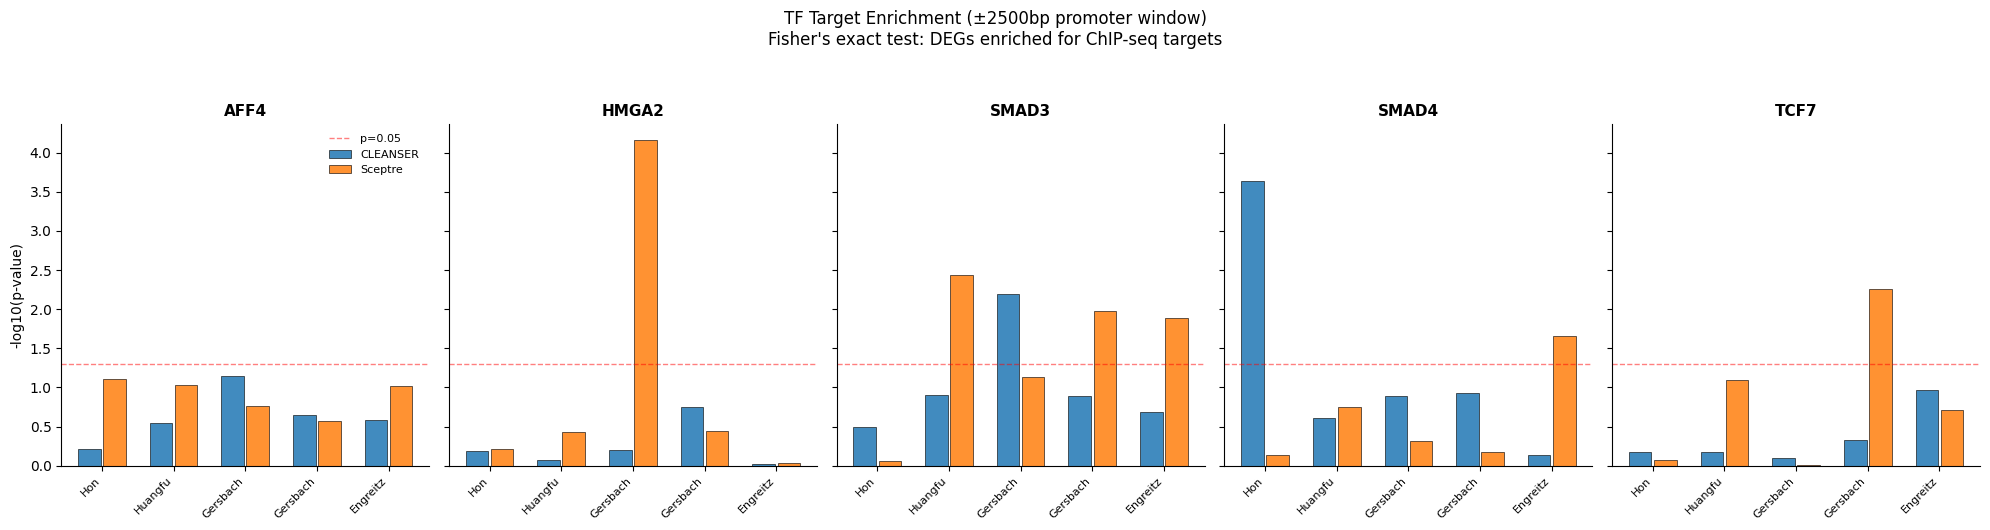

In [ ]:
# TF enrichment barplots: -log10(pvalue) per TF, grouped by dataset, CLEANSER vs Sceptre side by side
# Use promoter_window_width = 2500 as a reasonable middle ground

WINDOW = 2500
tf_plot = tf_enrich[tf_enrich["promoter_window_width"] == WINDOW].copy()
tfs = sorted(tf_plot["TF_display"].unique())
ds_labs = [short_name(ds) for ds in dataset_order]

run_colors = {"CLEANSER": "#1f77b4", "Sceptre": "#ff7f0e"}

fig, axes = plt.subplots(1, len(tfs), figsize=(4 * len(tfs), 5), sharey=True)
x = np.arange(len(ds_labs))
width = 0.35

for ax, tf in zip(axes, tfs):
    for j, (run, run_label) in enumerate(RUN_DISPLAY.items()):
        run_df = tf_plot[(tf_plot["TF_display"] == tf) & (tf_plot["run"] == run)]
        vals = []
        for sn in ds_labs:
            row = run_df[run_df["lab"] == sn]
            vals.append(row["neg_log10_pval"].values[0] if len(row) > 0 else 0)
        offset = (j - 0.5) * width
        ax.bar(x + offset, vals, width * 0.9, label=run_label,
               color=run_colors[run_label], edgecolor="black", linewidth=0.5, alpha=0.85)
    
    ax.axhline(-np.log10(0.05), color="red", linestyle="--", alpha=0.5, linewidth=1, label="p=0.05")
    ax.set_xticks(x)
    ax.set_xticklabels([sn.split()[0] for sn in ds_labs], fontsize=8, rotation=45, ha="right")
    ax.set_title(tf, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("-log10(p-value)", fontsize=10)
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle(f"TF Target Enrichment (±{WINDOW}bp promoter window)\n"
             f"Fisher's exact test: DEGs enriched for ChIP-seq targets",
             fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tf_enrichment_barplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

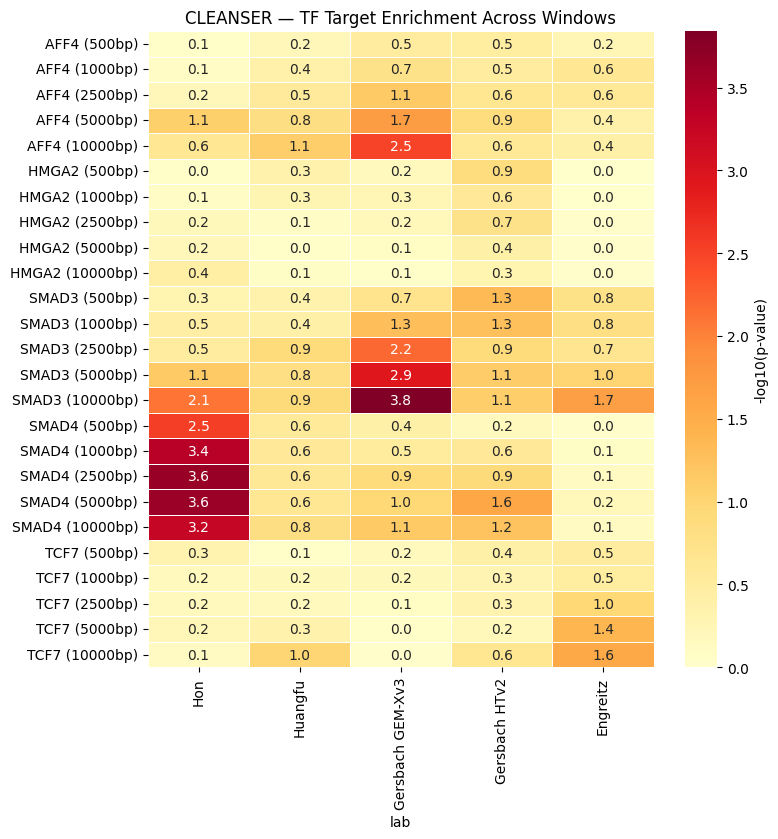

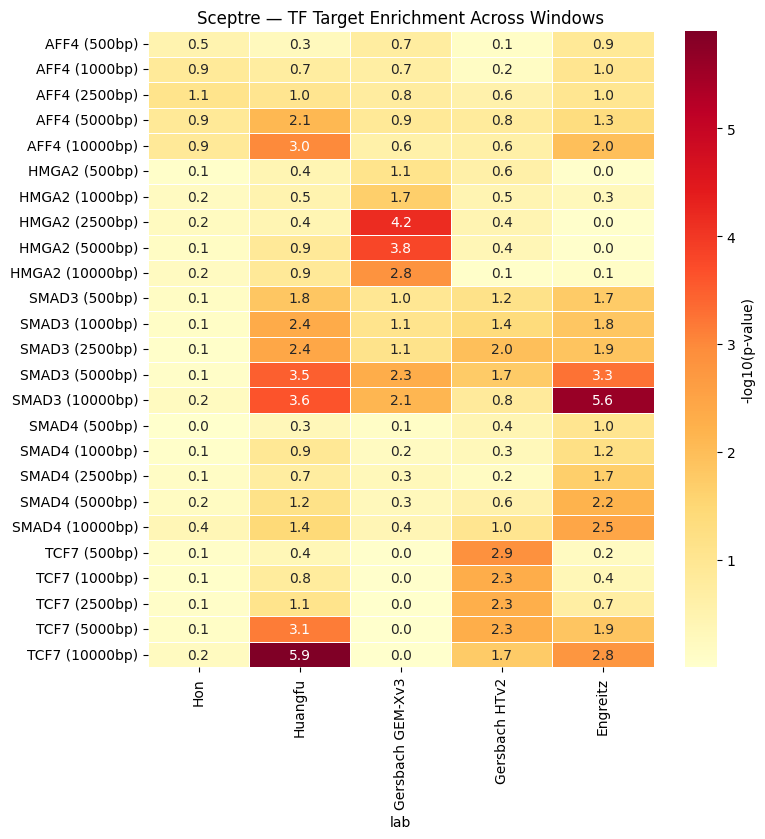

In [ ]:
# TF enrichment across window sizes: heatmap of -log10(pvalue) per TF × dataset
# One heatmap per run
for run, run_label in RUN_DISPLAY.items():
    run_df = tf_enrich[tf_enrich["run"] == run].copy()
    
    for tf in tfs:
        tf_df = run_df[run_df["TF_display"] == tf]
        if tf_df.empty:
            continue
        
        pivot = tf_df.pivot_table(
            index="promoter_window_width", columns="lab", values="neg_log10_pval"
        )
        # Order columns
        pivot = pivot.reindex(columns=[sn for sn in ds_labs if sn in pivot.columns])
        
    # Build combined heatmap: rows = TF × window, cols = dataset
    run_df["row_label"] = run_df["TF_display"] + " (" + run_df["promoter_window_width"].astype(str) + "bp)"
    pivot = run_df.pivot_table(
        index=["TF_display", "promoter_window_width"], columns="lab", values="neg_log10_pval"
    )
    pivot = pivot.reindex(columns=[sn for sn in ds_labs if sn in pivot.columns])
    pivot.index = [f"{tf} ({w}bp)" for tf, w in pivot.index]
    
    fig_height = max(6, len(pivot) * 0.3 + 1)
    fig, ax = plt.subplots(figsize=(8, fig_height))
    
    sns.heatmap(pivot.fillna(0), annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                linewidths=0.5, cbar_kws={"label": "-log10(p-value)"})
    ax.set_title(f"{run_label} — TF Target Enrichment Across Windows")
    ax.set_ylabel("")
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"tf_enrichment_heatmap_{run}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

---

# DONE!